In [ ]:
import sys
import time
import serial
import glob
from matplotlib import pyplot as plt
import numpy as np
from helpers import (
    findDevice, set_voltage, set_current, get_par_MP, get_par_AMB,
    r_squared, plot_data_and_fit, set_par_gain, set_ambit_led_gain,
    set_ambit_led, ambit_reboot, AmbitInfo
)


In [2]:
# Initialize ports for MiniPAR
#PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)
PORT_MINIPAR_PAR = findDevice(question="get_name\n",answer="Par_REF",flush=True,timeout=2)
PORT_MINIPAR_EMIT = findDevice(question="get_name\n",answer="Emit_LED",flush=True,timeout=2)


Received message: , port: /dev/ttyUSB0
Received message: 181149, port: /dev/ttyACM2
Received message: [spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
Ready
Emit_LED, port: /dev/ttyACM1
Received message: [spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
Ready
Par_REF, port: /dev/ttyACM0
Found device at: /dev/ttyACM0, answer: [spectrometer-debug] reason=boot attempts=1 ack=1 as7343_id_ok=1 as7343_id=0x00 as7341_id_ok=1 as7341_id=0x24 result=AS7341 init_ok=1
Spectrometer detected: AS7341
Ready
Par_REF

Received message: , port: /dev/ttyUSB0
Received message: 181149, port: /dev/ttyACM2
Received message: Emit_LED, port: /dev/ttyACM1
Found device at: /dev/ttyACM1, answer: Emit_LED



In [3]:
# Initialize ports for DC supply
PORT_DC_SOURCE = findDevice(question="*IDN?\n", answer="KIPRIM", flush=True, timeout=2)

Received message: KIPRIM,DC310S,25011669,FV:V5.2.0, port: /dev/ttyUSB0
Found device at: /dev/ttyUSB0, answer: KIPRIM,DC310S,25011669,FV:V5.2.0



In [5]:
# Initialize ports for Ambit
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
if(PORT_AMBIT is None):
    PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)


Received message: , port: /dev/ttyUSB0
Received message: BAD COMMAND
248, port: /dev/ttyACM2
Received message: MiniPAR,V1.1, port: /dev/ttyACM1
Received message: MiniPAR,V1.1, port: /dev/ttyACM0
No matching device found.
Received message: , port: /dev/ttyUSB0
Received message: NEW Name Here Ready, port: /dev/ttyACM2
Found device at: /dev/ttyACM2, answer: NEW Name Here Ready



In [6]:
# Check if devices are detected
if PORT_MINIPAR_PAR is None:
    print("MiniPAR PAR device not found.")
    exit(1)
if PORT_MINIPAR_EMIT is None:
    print("MiniPAR Emit LED device not found.")
    exit(1)
if PORT_AMBIT is None:
    print("Ambit device not found.") 
    exit(1)
if PORT_DC_SOURCE is None:
    print("DC Source device not found.")
    exit(1)

print("All devices detected")

print(get_par_MP(PORT_MINIPAR_PAR, raw=True))
print(get_par_MP(PORT_MINIPAR_EMIT, raw=True))
print(get_par_AMB(PORT_AMBIT, raw = True))

All devices detected
0.28
0.29
4.13


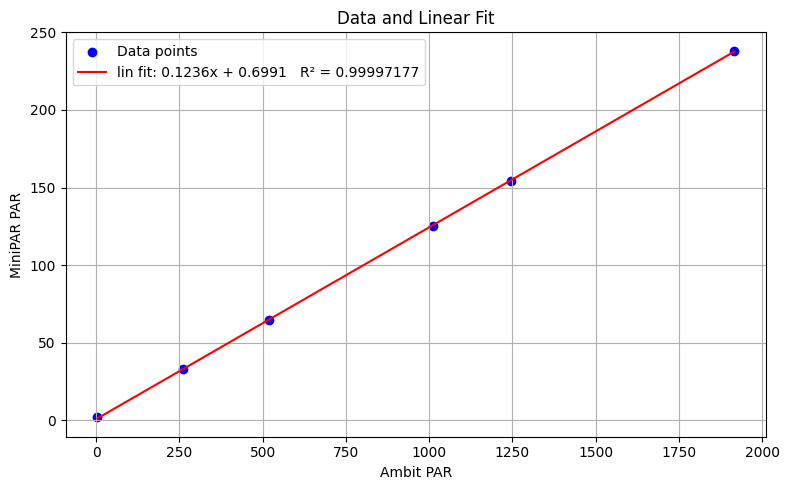

In [ ]:
# callibration of the light sensor in the Ambit

currents = [0.2, 0.4, 0.8, 1.0, 1.6, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_current(port=PORT_DC_SOURCE, current=I)
    time.sleep(1.0)
    ref_val = get_par_MP(PORT_MINIPAR_PAR)
    sens_val = get_par_AMB(PORT_AMBIT, raw=True)
    reference_data.append(ref_val)
    sensor_data.append(sens_val)

# Analysis functions
# (r_squared and plot_data_and_fit are now imported from helpers.py)

y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)
plot_data_and_fit(x, y, coeffs, r2, xlabel="Ambit PAR", ylabel="MiniPAR PAR")

# info about the fit
info = ambit_reboot(PORT_AMBIT)
print("Old ambit PAR coefficient:", info.act_led_coeff)
plot_data_and_fit(x,y, coeffs, r2, ylabel="Ambit LED setting", xlabel="MiniPAR PAR")
 

In [20]:
# Upload PAR calibration coefficients to the Ambit
# This section demonstrates how to use set_par_gain
from helpers import set_par_gain, ambit_reboot, AmbitInfo

# Example:
slope = coeffs[0]
#offset = coeffs[1]
info = ambit_reboot(PORT_AMBIT)
old_slope =info.light_slope
print(f"Uploading PAR gain: {slope:.4f}")
set_par_gain(PORT_AMBIT, slope)
info = ambit_reboot(PORT_AMBIT)

print(f"Old PAR gain: {old_slope:.4f}, New PAR gain: {info.light_slope:.4f}") 

Uploading PAR gain: 0.1309
Old PAR gain: 0.1901, New PAR gain: 0.1309


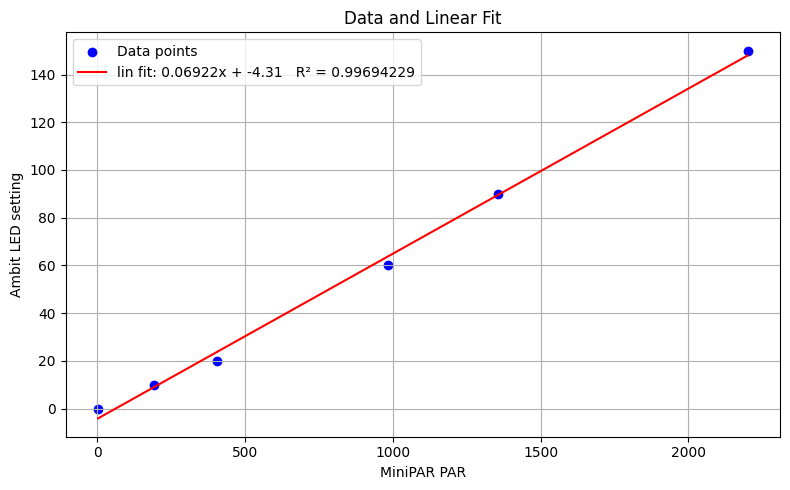

In [22]:
# Callibration of the light emmission of the Ambit LED
#ambit_reboot(PORT_AMBIT)
currents = [  10, 20, 60, 90, 150, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_ambit_led(PORT_AMBIT, I)
    time.sleep(0.2)
    sens_val = get_par_MP(PORT_MINIPAR_EMIT)
    reference_data.append(I)
    sensor_data.append(sens_val)
   
# inspection plot for LED callibration
y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, ylabel="Ambit LED setting", xlabel="MiniPAR PAR")

In [23]:
# Upload LED gain calibration to the Ambit
light_gain = coeffs[0]
info = ambit_reboot(PORT_AMBIT)
old_slope = info.act_led_coeff
set_ambit_led_gain(PORT_AMBIT, light_gain)
info = ambit_reboot(PORT_AMBIT)
print(f"Old LED gain: {old_slope:.4f}, New LED gain: {info.act_led_coeff:.4f}")

Old LED gain: 1421.7687, New LED gain: 0.0692


In [ ]:
# optional check of the sensor health
# PAR sensor cross-check

set_current(port=PORT_DC_SOURCE, current=1.2)
time.sleep(1.0)
s1 = get_par_MP(PORT_MINIPAR_PAR)
s2 = get_par_MP(PORT_MINIPAR_EMIT)

print(f"PAR reading from PAR sensor: {s1:.4f}")
print(f"PAR reading from LED sensor: {s2:.4f}")
set_current(port=PORT_DC_SOURCE, current=0.0)

PAR reading from PAR sensor: 182.4200
PAR reading from LED sensor: 182.3800


In [ ]:
# Continuous monitoring of the PAR sensor (press Ctrl+C to stop)
set_current(port=PORT_DC_SOURCE, current=1.0)
time.sleep(1.0)
try:
    while True:
        s1 = get_par_MP(PORT_MINIPAR_PAR)
        print(f"PAR reading from PAR sensor: {s1:.4f}")
except KeyboardInterrupt:
    pass

set_current(port=PORT_DC_SOURCE, current=0.0)

PAR reading from PAR sensor: 153.1600
PAR reading from PAR sensor: 153.1200
PAR reading from PAR sensor: 153.0100
PAR reading from PAR sensor: 152.8500
